In [2]:
import os
import random
import time
import tracemalloc

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import os

print(os.getcwd())

C:\Users\sammu


In [6]:
os.makedirs("results", exist_ok=True)
os.makedirs("graphs", exist_ok=True)
os.makedirs("word_files", exist_ok=True)

print("Project setup completed successfully!")

Project setup completed successfully!


In [8]:
def measure_performance(func, *args):
    tracemalloc.start()

    start_time = time.perf_counter()

    result = func(*args)

    end_time = time.perf_counter()

    current_memory, peak_memory = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    execution_time = end_time - start_time
    memory_usage_kb = peak_memory / 1024

    return result, execution_time, memory_usage_kb

In [10]:
#Bubble Sort
def bubble_sort(arr):
    arr = arr.copy()
    n = len(arr)

    for i in range(n):

        swapped = False

        for j in range(0, n - i - 1):

            if arr[j] > arr[j + 1]:

                arr[j], arr[j + 1] = arr[j + 1], arr[j]

                swapped = True

        # If no elements were swapped,
        # the array is already sorted
        if not swapped:
            break

    return arr

In [12]:
#Insertion Sort
def insertion_sort(arr):
    arr = arr.copy()

    for i in range(1, len(arr)):

        key = arr[i]

        j = i - 1

        while j >= 0 and arr[j] > key:

            arr[j + 1] = arr[j]

            j -= 1

        arr[j + 1] = key

    return arr

In [14]:
#Merge Sort
def merge(left, right):

    result = []

    i = 0
    j = 0

    while i < len(left) and j < len(right):

        if left[i] <= right[j]:

            result.append(left[i])
            i += 1

        else:

            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result

In [16]:
def merge_sort(arr):

    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)

In [18]:
#Quick Sort
def partition(arr, low, high):

    # Choose the middle element as pivot
    mid = (low + high) // 2

    # Move pivot to the end
    arr[mid], arr[high] = arr[high], arr[mid]

    pivot = arr[high]

    i = low - 1

    for j in range(low, high):

        if arr[j] <= pivot:

            i += 1

            arr[i], arr[j] = arr[j], arr[i]

    arr[i + 1], arr[high] = arr[high], arr[i + 1]

    return i + 1

In [20]:
def quick_sort_recursive(arr, low, high):

    if low < high:

        pivot_index = partition(arr, low, high)

        quick_sort_recursive(arr, low, pivot_index - 1)

        quick_sort_recursive(arr, pivot_index + 1, high)

In [22]:
def quick_sort(arr):

    arr = arr.copy()

    quick_sort_recursive(arr, 0, len(arr) - 1)

    return arr

In [24]:
test_data = [5, 2, 9, 1, 7, 3]

sorting_algorithms = {
    "Bubble Sort": bubble_sort,
    "Insertion Sort": insertion_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

for name, algorithm in sorting_algorithms.items():

    result = algorithm(test_data)

    print(name)
    print("Original:", test_data)
    print("Sorted:  ", result)
    print()

Bubble Sort
Original: [5, 2, 9, 1, 7, 3]
Sorted:   [1, 2, 3, 5, 7, 9]

Insertion Sort
Original: [5, 2, 9, 1, 7, 3]
Sorted:   [1, 2, 3, 5, 7, 9]

Merge Sort
Original: [5, 2, 9, 1, 7, 3]
Sorted:   [1, 2, 3, 5, 7, 9]

Quick Sort
Original: [5, 2, 9, 1, 7, 3]
Sorted:   [1, 2, 3, 5, 7, 9]



In [26]:
def generate_input_data(size):
    # Generate
    random_data = [random.randint(1, 100000) for _ in range(size)]

    sorted_data = sorted(random_data)

   
    reverse_sorted_data = sorted(random_data, reverse=True)

    return {
        "Sorted": sorted_data,
        "Reverse Sorted": reverse_sorted_data,
        "Random": random_data
    }

In [28]:
test_sizes = [100, 300, 500, 1000, 2000]

print("Test sizes:", test_sizes)

Test sizes: [100, 300, 500, 1000, 2000]


In [30]:
sorting_results = []

for size in test_sizes:

    print(f"\nTesting input size: {size}")

    input_conditions = generate_input_data(size)

    for condition, data in input_conditions.items():

        print(f"  Condition: {condition}")

        for algorithm_name, algorithm_function in sorting_algorithms.items():

            # Measure performance
            result, execution_time, memory_usage = measure_performance(
                algorithm_function,
                data
            )

            # Verify that the result is correctly sorted
            if result != sorted(data):
                print(f"    ERROR: {algorithm_name} did not sort correctly!")

            sorting_results.append({
                "Input Size": size,
                "Condition": condition,
                "Algorithm": algorithm_name,
                "Execution Time (seconds)": execution_time,
                "Memory Usage (KB)": memory_usage
            })

            print(
                f"    {algorithm_name}: "
                f"{execution_time:.6f} sec, "
                f"{memory_usage:.2f} KB"
            )


Testing input size: 100
  Condition: Sorted
    Bubble Sort: 0.000029 sec, 0.89 KB
    Insertion Sort: 0.000020 sec, 0.86 KB
    Merge Sort: 0.000604 sec, 1.98 KB
    Quick Sort: 0.000272 sec, 0.86 KB
  Condition: Reverse Sorted
    Bubble Sort: 0.001097 sec, 0.89 KB
    Insertion Sort: 0.000563 sec, 0.86 KB
    Merge Sort: 0.001366 sec, 146.83 KB
    Quick Sort: 0.000250 sec, 0.86 KB
  Condition: Random
    Bubble Sort: 0.000776 sec, 0.89 KB
    Insertion Sort: 0.000314 sec, 0.86 KB
    Merge Sort: 0.000654 sec, 1.78 KB
    Quick Sort: 0.000274 sec, 0.86 KB

Testing input size: 300
  Condition: Sorted
    Bubble Sort: 0.000125 sec, 2.54 KB
    Insertion Sort: 0.000175 sec, 2.48 KB
    Merge Sort: 0.002041 sec, 5.89 KB
    Quick Sort: 0.001393 sec, 2.83 KB
  Condition: Reverse Sorted
    Bubble Sort: 0.014358 sec, 2.57 KB
    Insertion Sort: 0.008768 sec, 2.48 KB
    Merge Sort: 0.003115 sec, 6.66 KB
    Quick Sort: 0.002172 sec, 2.91 KB
  Condition: Random
    Bubble Sort: 0.014859 s

In [32]:
sorting_df = pd.DataFrame(sorting_results)

sorting_df.head()

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
0,100,Sorted,Bubble Sort,0.000029,0.890625
1,100,Sorted,Insertion Sort,0.000020,0.859375
2,100,Sorted,Merge Sort,0.000604,1.984375
3,100,Sorted,Quick Sort,0.000272,0.859375
4,100,Reverse Sorted,Bubble Sort,0.001097,0.890625


In [34]:
print("Total experiments completed:", len(sorting_df))

Total experiments completed: 60


In [36]:
sorting_df.to_csv(
    "results/sorting_results.csv",
    index=False
)

print("Sorting results saved successfully!")

Sorting results saved successfully!


In [38]:
def fib_recursive(n):
    if n <= 1:
        return n

    return fib_recursive(n - 1) + fib_recursive(n - 2)

In [40]:
def fib_iterative(n):
    if n <= 1:
        return n

    a, b = 0, 1

    for _ in range(2, n + 1):
        a, b = b, a + b

    return b

In [42]:
def fib_dp(n, memo=None):

    if memo is None:
        memo = {}

    if n in memo:
        return memo[n]

    if n <= 1:
        return n

    memo[n] = fib_dp(n - 1, memo) + fib_dp(n - 2, memo)

    return memo[n]

In [44]:
test_n = 10

print("Testing Fibonacci algorithms for n =", test_n)

print("Recursive:", fib_recursive(test_n))
print("Iterative:", fib_iterative(test_n))
print("Dynamic Programming:", fib_dp(test_n))

Testing Fibonacci algorithms for n = 10
Recursive: 55
Iterative: 55
Dynamic Programming: 55


In [46]:
fibonacci_algorithms = {
    "Recursive Fibonacci": fib_recursive,
    "Iterative Fibonacci": fib_iterative,
    "Dynamic Programming Fibonacci": fib_dp
}

In [48]:
fib_sizes = [5, 10, 15, 20, 25, 30, 35]

In [50]:
fibonacci_results = []

for n in fib_sizes:

    print(f"\nTesting Fibonacci for n = {n}")

    for algorithm_name, algorithm_function in fibonacci_algorithms.items():

        result, execution_time, memory_usage = measure_performance(
            algorithm_function,
            n
        )

        fibonacci_results.append({
            "Input Size (n)": n,
            "Algorithm": algorithm_name,
            "Fibonacci Value": result,
            "Execution Time (seconds)": execution_time,
            "Memory Usage (KB)": memory_usage
        })

        print(
            f"  {algorithm_name}: "
            f"Value = {result}, "
            f"Time = {execution_time:.6f} sec, "
            f"Memory = {memory_usage:.2f} KB"
        )


Testing Fibonacci for n = 5
  Recursive Fibonacci: Value = 5, Time = 0.000005 sec, Memory = 0.00 KB
  Iterative Fibonacci: Value = 5, Time = 0.000013 sec, Memory = 0.08 KB
  Dynamic Programming Fibonacci: Value = 5, Time = 0.000008 sec, Memory = 0.16 KB

Testing Fibonacci for n = 10
  Recursive Fibonacci: Value = 55, Time = 0.000022 sec, Memory = 0.00 KB
  Iterative Fibonacci: Value = 55, Time = 0.000004 sec, Memory = 0.08 KB
  Dynamic Programming Fibonacci: Value = 55, Time = 0.000008 sec, Memory = 0.44 KB

Testing Fibonacci for n = 15
  Recursive Fibonacci: Value = 610, Time = 0.000184 sec, Memory = 0.06 KB
  Iterative Fibonacci: Value = 610, Time = 0.000006 sec, Memory = 0.09 KB
  Dynamic Programming Fibonacci: Value = 610, Time = 0.000014 sec, Memory = 0.84 KB

Testing Fibonacci for n = 20
  Recursive Fibonacci: Value = 6765, Time = 0.002004 sec, Memory = 0.16 KB
  Iterative Fibonacci: Value = 6765, Time = 0.000012 sec, Memory = 0.12 KB
  Dynamic Programming Fibonacci: Value = 676

In [52]:
fibonacci_df = pd.DataFrame(fibonacci_results)

fibonacci_df

,Input Size (n),Algorithm,Fibonacci Value,Execution Time (seconds),Memory Usage (KB)
0,5,Recursive Fibonacci,5,0.000005,0.000000
1,5,Iterative Fibonacci,5,0.000013,0.078125
2,5,Dynamic Programming Fibonacci,5,0.000008,0.156250
3,10,Recursive Fibonacci,55,0.000022,0.000000
4,10,Iterative Fibonacci,55,0.000004,0.078125
5,10,Dynamic Programming Fibonacci,55,0.000008,0.437500
6,15,Recursive Fibonacci,610,0.000184,0.062500
7,15,Iterative Fibonacci,610,0.000006,0.093750
8,15,Dynamic Programming Fibonacci,610,0.000014,0.835938
9,20,Recursive Fibonacci,6765,0.002004,0.156250


In [54]:
print("Total Fibonacci experiments:", len(fibonacci_df))

Total Fibonacci experiments: 21


In [56]:
fibonacci_df.to_csv(
    "results/fibonacci_results.csv",
    index=False
)

print("Fibonacci results saved successfully!")

Fibonacci results saved successfully!


In [58]:
complexity_data = {
    "Algorithm": [
        "Bubble Sort",
        "Insertion Sort",
        "Merge Sort",
        "Quick Sort",
        "Recursive Fibonacci",
        "Iterative Fibonacci",
        "Dynamic Programming Fibonacci"
    ],

    "Best Case": [
        "O(n)",
        "O(n)",
        "O(n log n)",
        "O(n log n)",
        "O(2^n)",
        "O(n)",
        "O(n)"
    ],

    "Average Case": [
        "O(n²)",
        "O(n²)",
        "O(n log n)",
        "O(n log n)",
        "O(2^n)",
        "O(n)",
        "O(n)"
    ],

    "Worst Case": [
        "O(n²)",
        "O(n²)",
        "O(n log n)",
        "O(n²)",
        "O(2^n)",
        "O(n)",
        "O(n)"
    ],

    "Space Complexity": [
        "O(1)",
        "O(1)",
        "O(n)",
        "O(log n)",
        "O(n)",
        "O(1)",
        "O(n)"
    ]
}

complexity_df = pd.DataFrame(complexity_data)

complexity_df

,Algorithm,Best Case,Average Case,Worst Case,Space Complexity
0,Bubble Sort,O(n),O(n²),O(n²),O(1)
1,Insertion Sort,O(n),O(n²),O(n²),O(1)
2,Merge Sort,O(n log n),O(n log n),O(n log n),O(n)
3,Quick Sort,O(n log n),O(n log n),O(n²),O(log n)
4,Recursive Fibonacci,O(2^n),O(2^n),O(2^n),O(n)
5,Iterative Fibonacci,O(n),O(n),O(n),O(1)
6,Dynamic Programming Fibonacci,O(n),O(n),O(n),O(n)


In [60]:
complexity_df.to_csv(
    "results/complexity_comparison.csv",
    index=False
)

print("Complexity comparison table saved successfully!")

Complexity comparison table saved successfully!


In [62]:
print("COMPLEXITY COMPARISON TABLE")

display(complexity_df)

COMPLEXITY COMPARISON TABLE


,Algorithm,Best Case,Average Case,Worst Case,Space Complexity
0,Bubble Sort,O(n),O(n²),O(n²),O(1)
1,Insertion Sort,O(n),O(n²),O(n²),O(1)
2,Merge Sort,O(n log n),O(n log n),O(n log n),O(n)
3,Quick Sort,O(n log n),O(n log n),O(n²),O(log n)
4,Recursive Fibonacci,O(2^n),O(2^n),O(2^n),O(n)
5,Iterative Fibonacci,O(n),O(n),O(n),O(1)
6,Dynamic Programming Fibonacci,O(n),O(n),O(n),O(n)


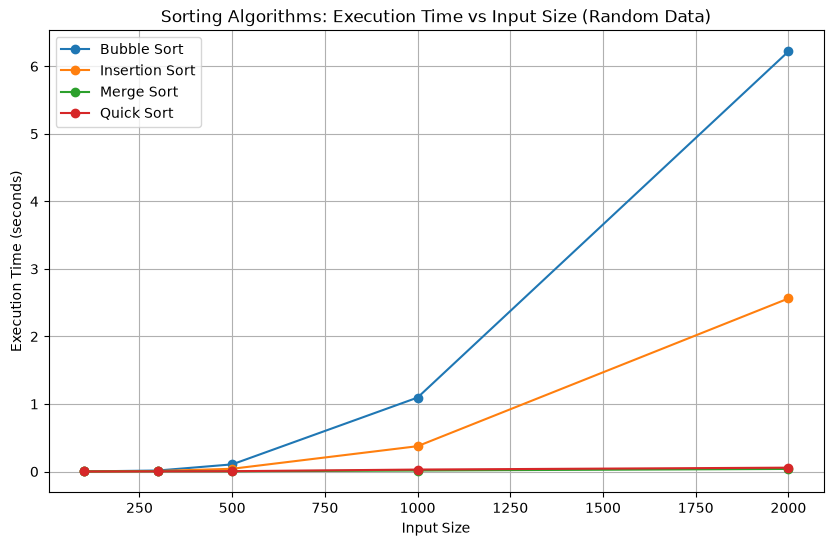

In [64]:
random_sorting_df = sorting_df[
    sorting_df["Condition"] == "Random"
]

plt.figure(figsize=(10, 6))

for algorithm in random_sorting_df["Algorithm"].unique():

    algorithm_data = random_sorting_df[
        random_sorting_df["Algorithm"] == algorithm
    ]

    plt.plot(
        algorithm_data["Input Size"],
        algorithm_data["Execution Time (seconds)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Sorting Algorithms: Execution Time vs Input Size (Random Data)")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/sorting_execution_time_random.png",
    bbox_inches="tight"
)

plt.show()

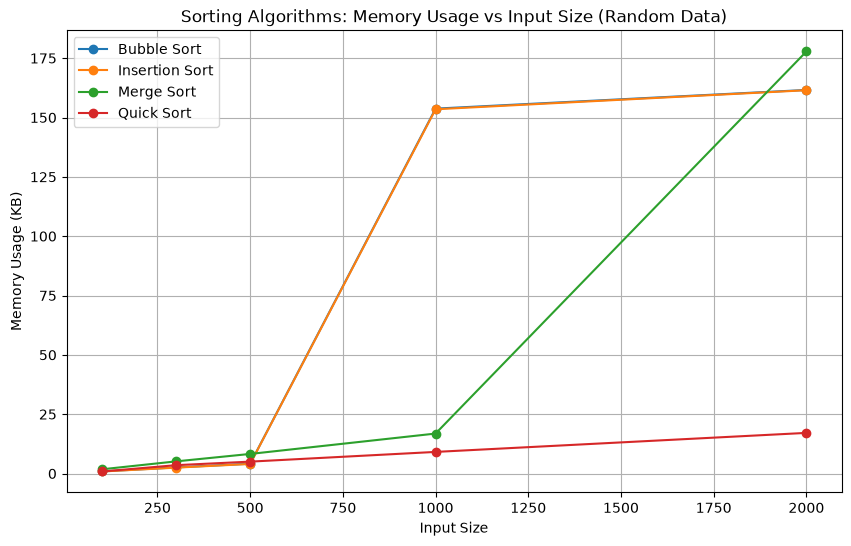

In [66]:
random_sorting_df = sorting_df[
    sorting_df["Condition"] == "Random"
]

plt.figure(figsize=(10, 6))

for algorithm in random_sorting_df["Algorithm"].unique():

    algorithm_data = random_sorting_df[
        random_sorting_df["Algorithm"] == algorithm
    ]

    plt.plot(
        algorithm_data["Input Size"],
        algorithm_data["Memory Usage (KB)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size")
plt.ylabel("Memory Usage (KB)")
plt.title("Sorting Algorithms: Memory Usage vs Input Size (Random Data)")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/sorting_memory_usage_random.png",
    bbox_inches="tight"
)

plt.show()

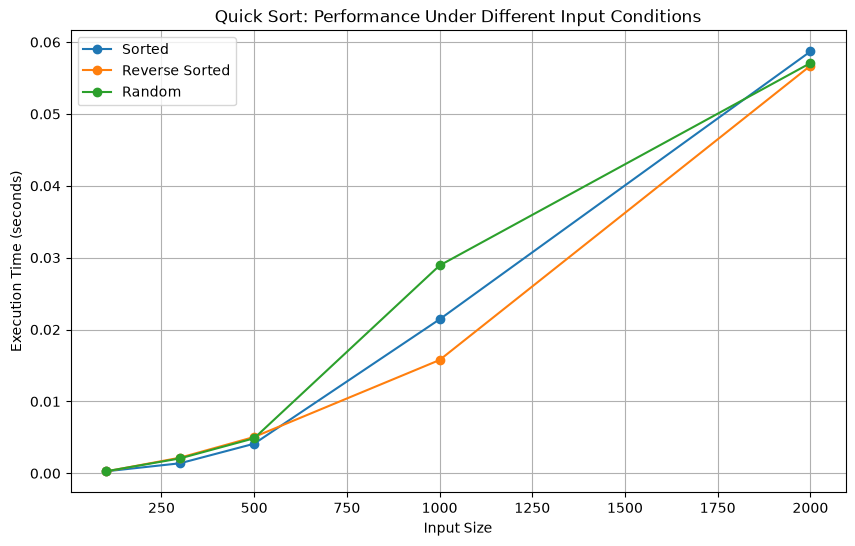

In [68]:
quick_sort_df = sorting_df[
    sorting_df["Algorithm"] == "Quick Sort"
]

plt.figure(figsize=(10, 6))

for condition in quick_sort_df["Condition"].unique():

    condition_data = quick_sort_df[
        quick_sort_df["Condition"] == condition
    ]

    plt.plot(
        condition_data["Input Size"],
        condition_data["Execution Time (seconds)"],
        marker="o",
        label=condition
    )

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Quick Sort: Performance Under Different Input Conditions")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/quick_sort_conditions.png",
    bbox_inches="tight"
)

plt.show()

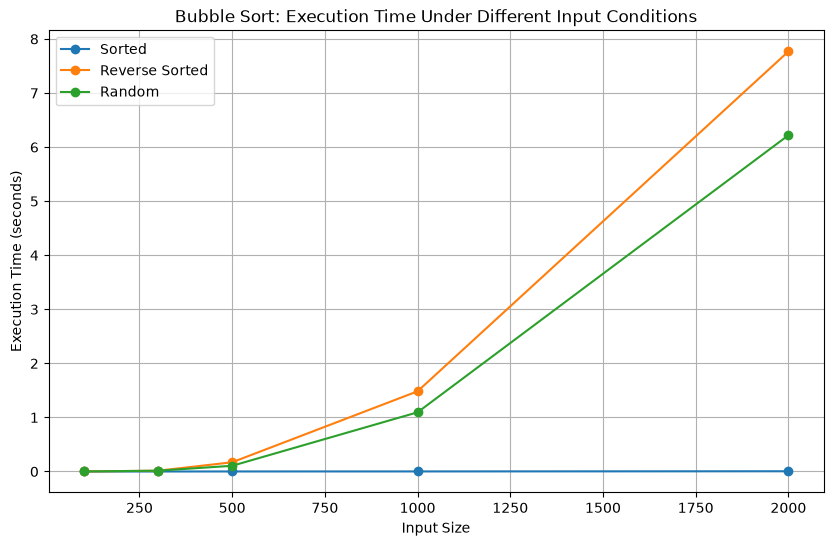

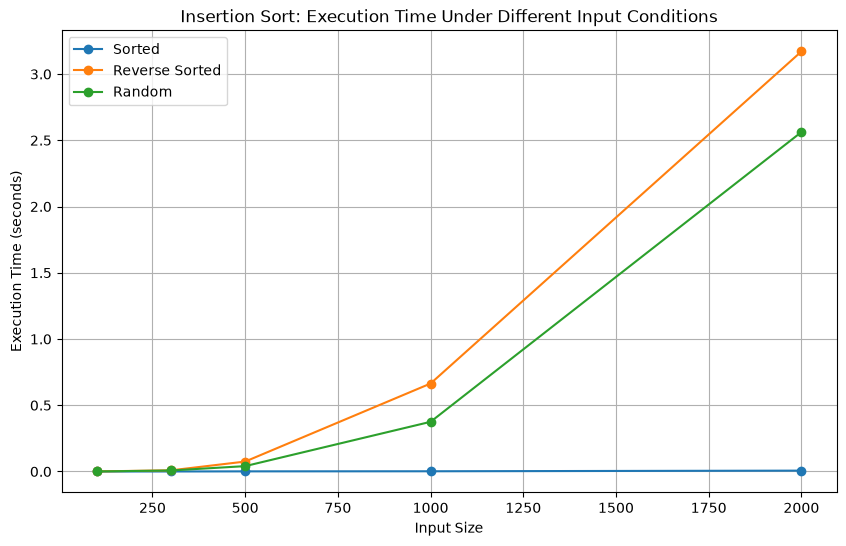

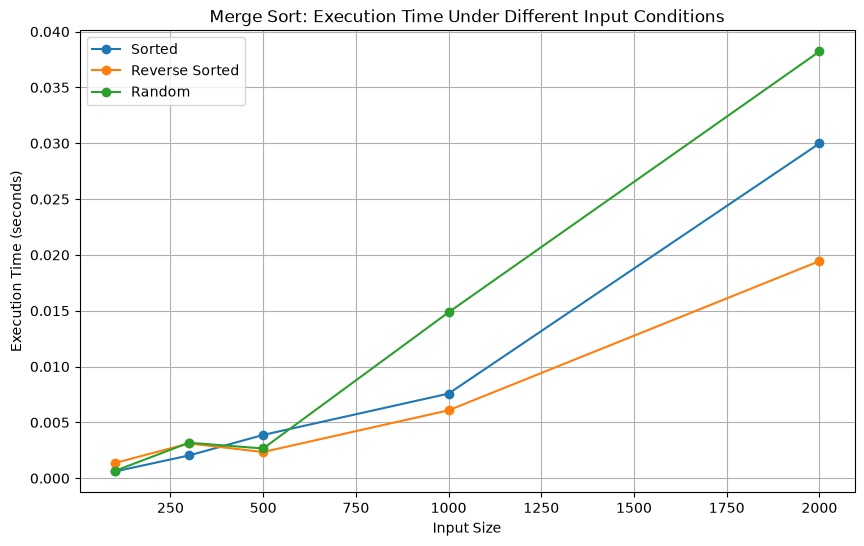

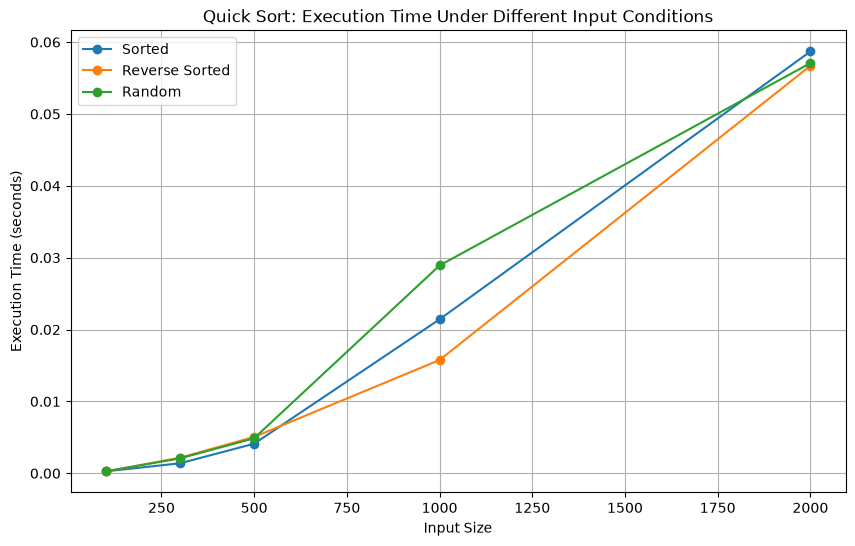

In [70]:
for algorithm in sorting_df["Algorithm"].unique():

    algorithm_df = sorting_df[
        sorting_df["Algorithm"] == algorithm
    ]

    plt.figure(figsize=(10, 6))

    for condition in algorithm_df["Condition"].unique():

        condition_data = algorithm_df[
            algorithm_df["Condition"] == condition
        ]

        plt.plot(
            condition_data["Input Size"],
            condition_data["Execution Time (seconds)"],
            marker="o",
            label=condition
        )

    plt.xlabel("Input Size")
    plt.ylabel("Execution Time (seconds)")
    plt.title(
        f"{algorithm}: Execution Time Under Different Input Conditions"
    )

    plt.legend()
    plt.grid(True)

    filename = algorithm.lower().replace(" ", "_")

    plt.savefig(
        f"graphs/{filename}_conditions.png",
        bbox_inches="tight"
    )

    plt.show()

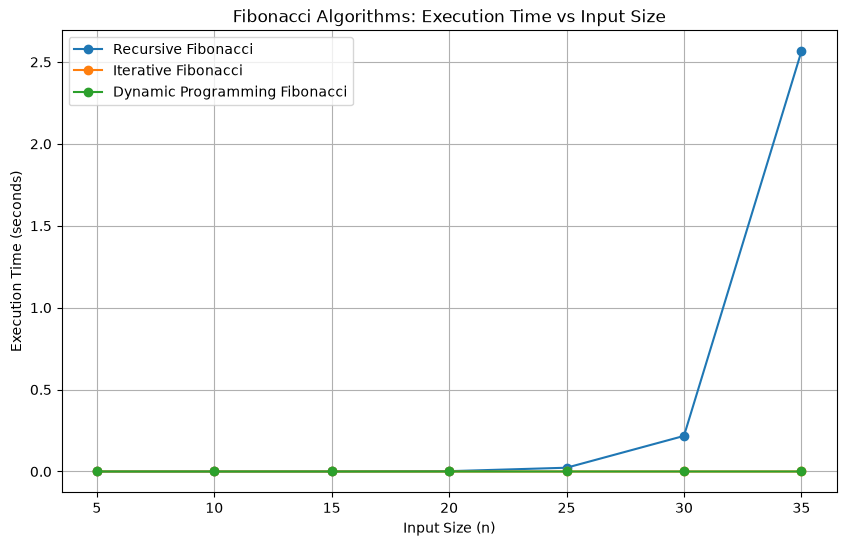

In [72]:
plt.figure(figsize=(10, 6))

for algorithm in fibonacci_df["Algorithm"].unique():

    algorithm_data = fibonacci_df[
        fibonacci_df["Algorithm"] == algorithm
    ]

    plt.plot(
        algorithm_data["Input Size (n)"],
        algorithm_data["Execution Time (seconds)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Fibonacci Algorithms: Execution Time vs Input Size")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/fibonacci_execution_time.png",
    bbox_inches="tight"
)

plt.show()

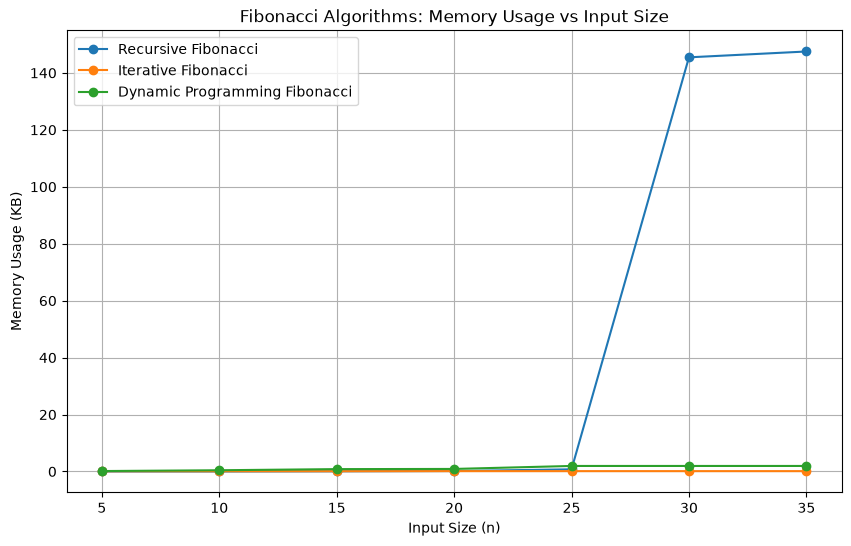

In [74]:
plt.figure(figsize=(10, 6))

for algorithm in fibonacci_df["Algorithm"].unique():

    algorithm_data = fibonacci_df[
        fibonacci_df["Algorithm"] == algorithm
    ]

    plt.plot(
        algorithm_data["Input Size (n)"],
        algorithm_data["Memory Usage (KB)"],
        marker="o",
        label=algorithm
    )

plt.xlabel("Input Size (n)")
plt.ylabel("Memory Usage (KB)")
plt.title("Fibonacci Algorithms: Memory Usage vs Input Size")
plt.legend()
plt.grid(True)

plt.savefig(
    "graphs/fibonacci_memory_usage.png",
    bbox_inches="tight"
)

plt.show()


In [76]:
import os

graph_files = os.listdir("graphs")

print("Generated Graph Files:")

for file in graph_files:
    print("-", file)

Generated Graph Files:
- bubble_sort_conditions.png
- fibonacci_execution_time.png
- fibonacci_memory_usage.png
- insertion_sort_conditions.png
- merge_sort_conditions.png
- quick_sort_conditions.png
- sorting_execution_time_random.png
- sorting_memory_usage_random.png


In [80]:
sorting_df[sorting_df["Condition"] == "Sorted"]

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
0,100,Sorted,Bubble Sort,0.000029,0.890625
1,100,Sorted,Insertion Sort,0.000020,0.859375
2,100,Sorted,Merge Sort,0.000604,1.984375
3,100,Sorted,Quick Sort,0.000272,0.859375
12,300,Sorted,Bubble Sort,0.000125,2.542969
13,300,Sorted,Insertion Sort,0.000175,2.480469
14,300,Sorted,Merge Sort,0.002041,5.890625
15,300,Sorted,Quick Sort,0.001393,2.828125
24,500,Sorted,Bubble Sort,0.000782,4.105469
25,500,Sorted,Insertion Sort,0.001058,4.042969


In [84]:
sorting_df[sorting_df["Condition"] == "Random"]

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
8,100,Random,Bubble Sort,0.000776,0.890625
9,100,Random,Insertion Sort,0.000314,0.859375
10,100,Random,Merge Sort,0.000654,1.781250
11,100,Random,Quick Sort,0.000274,0.859375
20,300,Random,Bubble Sort,0.014859,2.574219
21,300,Random,Insertion Sort,0.007695,2.480469
22,300,Random,Merge Sort,0.003182,5.117188
23,300,Random,Quick Sort,0.002073,3.518555
32,500,Random,Bubble Sort,0.105618,4.136719
33,500,Random,Insertion Sort,0.040521,4.042969


In [82]:
sorting_df[sorting_df["Condition"] == "Reverse Sorted"]

,Input Size,Condition,Algorithm,Execution Time (seconds),Memory Usage (KB)
4,100,Reverse Sorted,Bubble Sort,0.001097,0.890625
5,100,Reverse Sorted,Insertion Sort,0.000563,0.859375
6,100,Reverse Sorted,Merge Sort,0.001366,146.833008
7,100,Reverse Sorted,Quick Sort,0.000250,0.859375
16,300,Reverse Sorted,Bubble Sort,0.014358,2.574219
17,300,Reverse Sorted,Insertion Sort,0.008768,2.480469
18,300,Reverse Sorted,Merge Sort,0.003115,6.664062
19,300,Reverse Sorted,Quick Sort,0.002172,2.906250
28,500,Reverse Sorted,Bubble Sort,0.170700,151.369141
29,500,Reverse Sorted,Insertion Sort,0.075062,148.593750


In [86]:
fibonacci_df

,Input Size (n),Algorithm,Fibonacci Value,Execution Time (seconds),Memory Usage (KB)
0,5,Recursive Fibonacci,5,0.000005,0.000000
1,5,Iterative Fibonacci,5,0.000013,0.078125
2,5,Dynamic Programming Fibonacci,5,0.000008,0.156250
3,10,Recursive Fibonacci,55,0.000022,0.000000
4,10,Iterative Fibonacci,55,0.000004,0.078125
5,10,Dynamic Programming Fibonacci,55,0.000008,0.437500
6,15,Recursive Fibonacci,610,0.000184,0.062500
7,15,Iterative Fibonacci,610,0.000006,0.093750
8,15,Dynamic Programming Fibonacci,610,0.000014,0.835938
9,20,Recursive Fibonacci,6765,0.002004,0.156250


In [88]:
complexity_df

,Algorithm,Best Case,Average Case,Worst Case,Space Complexity
0,Bubble Sort,O(n),O(n²),O(n²),O(1)
1,Insertion Sort,O(n),O(n²),O(n²),O(1)
2,Merge Sort,O(n log n),O(n log n),O(n log n),O(n)
3,Quick Sort,O(n log n),O(n log n),O(n²),O(log n)
4,Recursive Fibonacci,O(2^n),O(2^n),O(2^n),O(n)
5,Iterative Fibonacci,O(n),O(n),O(n),O(1)
6,Dynamic Programming Fibonacci,O(n),O(n),O(n),O(n)
